# Imports

In [90]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*anndata.*", category=FutureWarning)

# - dirs 
from ciim.src.common import datasets_all, aging_clock_train_datasets, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_sig_stats
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
from ciim.src.insilico_perturbation.plots import plot_age_acceleration
from ciim.src.utils.util import get_genesets

reg_type = 'ridge'
version = 'v1.0'
data_type = 'bulk'

n_jobs = 1
simulation_iteration = 3
n_donors = 20

cell_types = ['CD8T'] #['CD4T', 'CD8T',  'NK', 'MONO']

# Pathway genes perturbation

In [138]:
from ciim.src.tf_activity.helper import get_consensus_net
cell_type = 'CD8T'
target_pathway = 'MYC TARGETS V1' # 'MTORC1 SIGNALING'  'MYC TARGETS V1'
tf_selection_type = 'top_enriched_tfs' #  'top_tfs', 'top_enriched_tfs'

pathways = get_genesets()
pathway_genes = pathways[target_pathway]
grn = get_consensus_net(cell_type=cell_type)
grn_pathway = grn[grn['target'].isin(pathway_genes)]

In [139]:
if False:
    from ciim.src.utils.util import get_genesets
    terms = []
    for term in pathways.keys():
        if ('mtor' in term.lower()) | ('ampk' in term.lower()):
            print(term, len(pathways[term]))
            terms.append(term)
    pathways = {k: pathways[k] for k in terms}

## Top regulators of the pathway genes: overall regualtors

Text(0.5, 1.0, ' CD8T: MYC TARGETS V1')

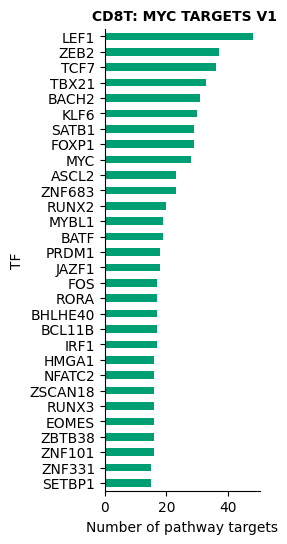

In [140]:
tf_counts = grn_pathway['source'].value_counts().sort_values(ascending=False)

# Plot
tf_counts_top = tf_counts.head(30)  # Limit to top 20 TFs for clarity
fig, ax = plt.subplots(figsize=(2, max(2, len(tf_counts_top) * 0.2)))
tf_counts_top.plot(kind='barh', ax=ax, color=colors_blind[2], edgecolor=None)

# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Number of pathway targets')
ax.set_ylabel('TF')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.margins(y=0.1)  # Add margins for better visibility
ax.set_title(f' {cell_type}: {target_pathway}', weight='bold', fontsize=10)


## To regulators of the given pathway genes: enriched regulators

In [141]:
from scipy.stats import fisher_exact

# All TFs in the GRN
all_tfs = grn['source'].unique()

# Set of all targets and pathway targets
all_targets = set(grn['target'])
pathway_targets = set(pathway_genes) & all_targets  # keep only known targets

results = []

for tf in all_tfs:
    tf_targets = set(grn.loc[grn['source'] == tf, 'target'])

    a = len(tf_targets & pathway_targets)                     # TF → pathway target
    b = len(tf_targets - pathway_targets)                     # TF → non-pathway target
    c = len(pathway_targets - tf_targets)                     # other TFs → pathway target
    d = len((all_targets - pathway_targets) - (tf_targets - pathway_targets))  # other TFs → non-pathway

    # Skip TFs with no target or zero counts to avoid math errors
    if (a + b + c + d) == 0 or (a + b == 0) or (c + d == 0):
        continue

    # Fisher's exact test
    oddsratio, pval = fisher_exact([[a, b], [c, d]], alternative='greater')  # test for over-representation

    results.append({
        'TF': tf,
        'n_pathway_targets': a,
        'n_total_targets': a + b,
        'odds_ratio': oddsratio,
        'pval': pval
    })

# Convert to DataFrame
df_enrich = pd.DataFrame(results)

# Adjust for multiple testing (optional)
from statsmodels.stats.multitest import multipletests
df_enrich['pval_adj'] = multipletests(df_enrich['pval'], method='fdr_bh')[1]

# Sort by significance
df_enrich = df_enrich[df_enrich['pval_adj'] < 0.05]
df_enrich = df_enrich.sort_values('pval')
df_enrich

,TF,n_pathway_targets,n_total_targets,odds_ratio,pval,pval_adj
79,NME2,11,49,13.282130,1.872610e-08,0.000003
39,HMGA1,16,154,5.714722,7.513565e-07,0.000063
120,TFAP4,12,86,7.478764,1.034456e-06,0.000063
101,SETBP1,15,151,5.302602,3.287452e-06,0.000131
153,ZNF331,15,152,5.261089,3.578882e-06,0.000131
...,...,...,...,...,...,...
172,ZNF683,23,569,1.990724,1.138680e-02,0.028941
37,HIVEP2,7,97,3.178960,1.170742e-02,0.029349
13,CEBPB,5,54,4.085798,1.210429e-02,0.029934
23,EOMES,16,356,2.069350,1.602695e-02,0.039106


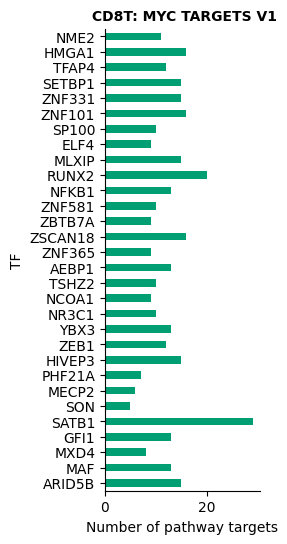

In [142]:
df = df_enrich.sort_values('pval_adj', ascending=True).head(30)
df = df[['TF', 'n_pathway_targets']].set_index('TF')
fig, ax = plt.subplots(figsize=(2, max(2, len(df) * 0.2)))
df.plot(kind='barh', ax=ax, color=colors_blind[2], edgecolor=None)

# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Number of pathway targets')
ax.set_ylabel('TF')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.margins(y=0.1)  # Add margins for better visibility
ax.set_title(f' {cell_type}: {target_pathway}', weight='bold', fontsize=10)
ax.get_legend().remove()  # Remove legend if not needed

## Run perturbation simulation for different selection of TFs

In [143]:
top_tfs_counts = [2, 5, 7, 10, 15, 20, 25, 50]
if tf_selection_type == 'top_tfs': # general regulators
    tfs_list = tf_counts.index.tolist()
elif tf_selection_type == 'top_enriched_tfs':
    tfs_list = df_enrich.sort_values('pval_adj', ascending=True)['TF'].tolist()
else:
    raise ValueError(f'Unknown tf_selection_type: {tf_selection_type}')

In [144]:
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
from collections import defaultdict

simulation_iteration = 3
n_donors = 20
n_jobs = 5
datasets = datasets_all

results = defaultdict(list)

raw_rr_store = []
for n in top_tfs_counts:
    # - get top N TFs regulating the pathway
    tfs = tfs_list[:n]

    par = {
        'simulation_iteration': simulation_iteration,
        'n_donors': n_donors,
        'data_type': data_type,
        'version': version,
        'reg_type': reg_type,
        'feature_type': 'gene_expression',
        'perturbation_mode': 'overexpression',
        'perturbation_type': 'multi',
        'tfs': tfs,
    }
    raw_rr = wrapper_in_silico_perturbation(par, n_jobs=n_jobs, cell_types=cell_types, datasets=datasets)
    raw_rr['n'] = n
    raw_rr_store.append(raw_rr)

raw_rr = pd.concat(raw_rr_store).reset_index()

Processing: CD8T - data13_Korean (overexpression | multi)Processing: CD8T - data7_allTPs_jalil (overexpression | multi)

Processing: CD8T - data12 (overexpression | multi)
Processing: CD8T - data1 (overexpression | multi)
Processing: CD8T - SLE_European (overexpression | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scor

## Plot age shift and gene score shift per donor

In [145]:
if False: # donor level plot
    from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
    datasets = raw_rr['dataset'].unique()
    n_datasets = len(datasets)
    # for n in raw_rr['n'].unique():
    for n in [10]:
        rr = raw_rr[raw_rr['n'] == n].copy()
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            rr_sub = rr[(rr['cell_type'] == cell_type) & (rr['dataset'] == dataset)].copy()
            df = rr_sub['age_shift']
            df['donor_age'] = rr_sub['donor_age']
            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"{cell_type}: {n}", y=1.25, fontsize=12, fontweight='bold')

## Plot the effect of perturbation on aging pathways 

In [146]:
# - summary of pathway gene score shift
def average_over_donors():
    terms = list(get_genesets().keys())
    df_store = []
    for term in terms:
        if term not in raw_rr.columns:
            continue
        df_sub_store = []
        for i, col in enumerate(['baseline_gene_score', 'perturbed_gene_score' ,'gene_score_shift']):
            df = raw_rr.groupby(['cell_type', 'dataset', 'n'])[term].mean()[term][col].reset_index()
            if i == 0:
                df_sub_store.append(df)
            else:
                df_sub_store.append(df[[col]])
        df = pd.concat(df_sub_store, axis=1)
        df['pathway'] = term
        df_store.append(df)
    score_shift_summary = pd.concat(df_store).reset_index(drop=True)
    return score_shift_summary
score_shift_summary = average_over_donors()
# - subset to aging tfs
if False: 
    stats_sig = retrieve_sig_stats(feature_type='gene_score').drop_duplicates(subset=['cell_type', 'pathway'])[['pathway', 'cell_type', 'slope']].rename(columns={'slope': 'spearman_slope'})
    # stats_sig = stats_sig[stats_sig['spearman_slope'].abs() > 0.4] # # filter to pathways with significant aging slope -> move this to helper function
    score_shift_summary = score_shift_summary.merge(stats_sig, on=['cell_type', 'pathway'], how='inner')
    print(score_shift_summary.shape)
# print(df_pathway_score_shift_summary['pathway'].value_counts())
if False:
    # - calculate the natural aging slope
    from ciim.src.insilico_perturbation.helper import compute_slopes
    from ciim.src.tf_activity.helper import retrieve_feature_data
    slope_store = []
    for dataset in datasets:
        # adata = retrieve_feature_data(cell_type=cell_type, dataset=dataset)
        adata = ad.read_h5ad(f"{save_dir}/gene_expression_smoothed/{dataset}_{cell_type}_bulk.h5ad")
        slope = compute_slopes(adata, feature_type='gene_score')
        slope.index.name = 'pathway'
        slope = slope.reset_index()
        slope['dataset'] = dataset   
        slope_store.append(slope)
    df_slope = pd.concat(slope_store).reset_index(drop=True).rename(columns={'slope': 'aging_slope'})

    # - calculate 10 years slope
    df_slope['aging_slope'] = df_slope['aging_slope'] * 10  # convert to 10 years slope

    score_shift_summary = score_shift_summary.merge(df_slope, on=['dataset', 'pathway'], how='left')

    score_shift_summary['perturbation_effect'] = score_shift_summary['gene_score_shift'] / score_shift_summary['aging_slope']
else:
    baseline_adj = score_shift_summary['baseline_gene_score'].abs().quantile(.25)
    score_shift_summary['gene_score_shift_n'] = score_shift_summary['gene_score_shift'].abs() / (score_shift_summary['baseline_gene_score'] )

    score_shift_summary['gene_score_shift_log2fc'] = np.log2((score_shift_summary['gene_score_shift'].abs() + baseline_adj) / (score_shift_summary['baseline_gene_score'].abs() + baseline_adj))
score_shift_summary.head()

,cell_type,dataset,n,baseline_gene_score,perturbed_gene_score,gene_score_shift,pathway,gene_score_shift_n,gene_score_shift_log2fc
0,CD8T,SLE_European,2,0.139709,0.197143,0.057435,ADIPOGENESIS,0.411102,-0.769046
1,CD8T,SLE_European,5,0.139709,-0.027973,-0.167681,ADIPOGENESIS,1.200222,0.189646
2,CD8T,SLE_European,7,0.139709,0.004402,-0.135307,ADIPOGENESIS,0.968490,-0.032254
3,CD8T,SLE_European,10,0.139709,0.130371,-0.009337,ADIPOGENESIS,0.066834,-1.534276
4,CD8T,SLE_European,15,0.139709,-0.027786,-0.167495,ADIPOGENESIS,1.198885,0.188459


## Plot age shift and the target pathway's gene score shift for different TF selection

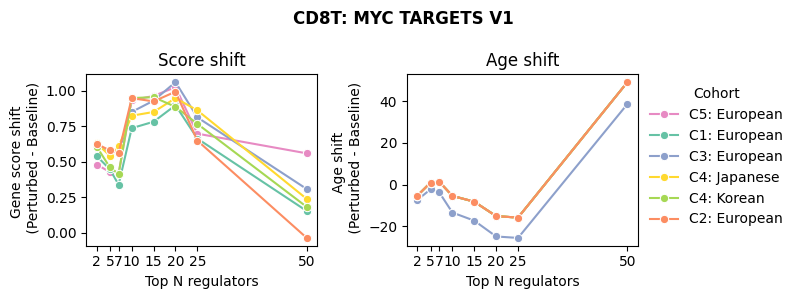

In [147]:

import seaborn as sns
import matplotlib.pyplot as plt

age_shift_summary = raw_rr.groupby(['cell_type', 'dataset', 'n'])['age_shift'].mean()['age_shift']['age_shift'].reset_index()
age_shift_summary['dataset'] = age_shift_summary['dataset'].map(surrogate_names)

gene_score_shift_summary = raw_rr.groupby(['cell_type', 'dataset', 'n'])[target_pathway].mean()[target_pathway]['gene_score_shift'].reset_index()
gene_score_shift_summary['dataset'] = gene_score_shift_summary['dataset'].map(surrogate_names)


fig, axes = plt.subplots(1, 2, figsize=(8, 3))

ax = axes[0]

sns.lineplot(data=gene_score_shift_summary, x='n', y='gene_score_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title(f'Score shift')
ax.set_ylabel('Gene score shift \n (Perturbed - Baseline)')
ax.set_xlabel('Top N regulators')
ax.set_xticks(top_tfs_counts)
ax.get_legend().remove()
ax = axes[1]
sns.lineplot(data=age_shift_summary, x='n', y='age_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title('Age shift')
ax.set_ylabel('Age shift \n (Perturbed - Baseline)')
ax.set_xlabel('Top N regulators')
ax.set_xticks(top_tfs_counts)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Cohort', frameon=False)
plt.suptitle(f'{cell_type}: {target_pathway}', fontsize=12, weight='bold')
plt.tight_layout()

### Per top n regulators perturbation: average over datasets

In [148]:
gene_score_shift_col = 'gene_score_shift_log2fc'

Text(0.5, 23.52222222222222, 'Number of top TFs perturbed')

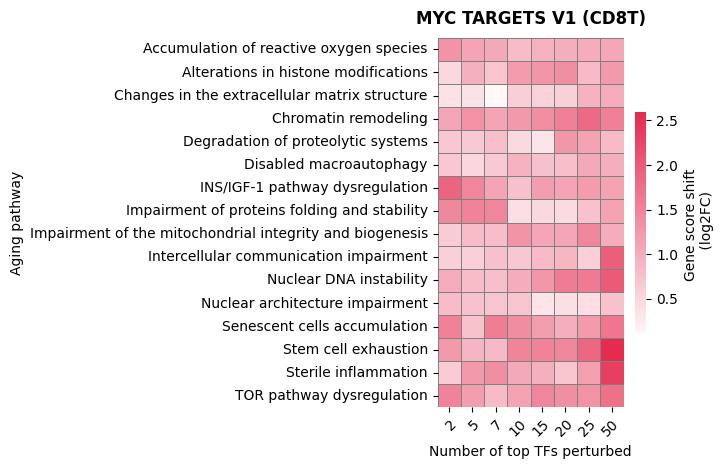

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def heatplot_perturbation_effect(pivot_df):
    from matplotlib.colors import LinearSegmentedColormap

    custom_cmap = LinearSegmentedColormap.from_list(
        'aging_effect_cmap',
        [palette_trend_2['Decrease in aging'], 'white', palette_trend_2['Increase in aging']]
    )
    fig, ax = plt.subplots(1, 1, figsize=(3, max(4, len(pivot_df) * 0.3)))
    cbar_label = 'Gene score shift \n (log2FC)' if 'log2fc' in gene_score_shift_col else 'Gene score shift'
    sns.heatmap(pivot_df, 
                cmap=custom_cmap, 
                center=0, 
                linewidths=0.5, 
                linecolor='gray',
                cbar_kws={'label': cbar_label, 'shrink': 0.6})
    ax.set_ylabel('Aging pathway')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# - opengenes 
opengenes_terms = get_genesets('opengenes')
df_summary_opengenes = score_shift_summary[score_shift_summary['pathway'].isin(opengenes_terms)]
df_summary_opengenes[gene_score_shift_col] = df_summary_opengenes[gene_score_shift_col].abs() # sign is not important here, we are interested in the magnitude of the shift
pivot_df = df_summary_opengenes.pivot_table(index='pathway', columns='n', values=gene_score_shift_col)

heatplot_perturbation_effect(pivot_df)
plt.title(f'{target_pathway} ({cell_type})', pad=10, fontsize=12, fontweight='bold')
plt.xlabel('Number of top TFs perturbed')

Text(0.5, 23.52222222222222, '')

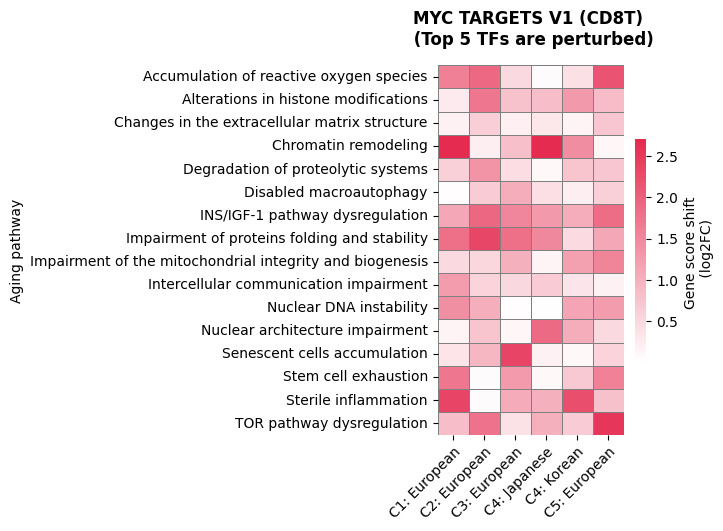

In [150]:
n = 5
df = df_summary_opengenes[df_summary_opengenes['n']==n].copy()
df['dataset'] = df['dataset'].apply(lambda x: surrogate_names[x] if x in surrogate_names else x)

pivot_df = df.pivot_table(index='pathway', columns='dataset', values=gene_score_shift_col)

heatplot_perturbation_effect(pivot_df)

plt.title(f'{target_pathway} ({cell_type}) \n (Top {n} TFs are perturbed)', pad=15, fontsize=12, fontweight='bold')
plt.xlabel('')

In [151]:
aaa 

NameError: name 'aaa' is not defined

# Single aging TF perturbation

In [41]:
if True:
    cmd = f"python ../src/insilico_perturbation/script.py \
        --cell_types {cell_types} \
        --reg_type {reg_type} \
        --simulation_iteration {simulation_iteration} \
        --n_donors {n_donors}"

    os.system(cmd)

Running single aging TF perturbation...
Processing: CD8T - data12 (overexpression | single)


In [ ]:
save_file=f"{save_dir}/perturbation/single_aging_tf_perturbation.csv"

perturb_rr = pd.read_csv(save_file)
print(f"Loaded {len(perturb_rr)} results from {save_file}")
print(perturb_rr['cell_type'].unique())

Loaded 11163 results from /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//perturbation/single_aging_tf_perturbation.csv
['CD8T']


## Check the normality of age shift

In [68]:
perturb_rr_mean = perturb_rr.groupby(['cell_type', 'dataset', 'tf'])['age_shift'].mean().reset_index(name='mean_diff')

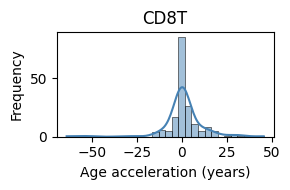

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Unique cell types
cell_types = perturb_rr_mean['cell_type'].unique()
n = len(cell_types)

# Determine subplot grid size
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2))
axes = axes.flatten()  # Flatten in case of 2D axes array

for i, cell_type in enumerate(cell_types):
    df = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type].copy()
    
    ax = axes[i]

    sns.histplot(df['mean_diff'], bins=30, kde=True, color='steelblue', ax=ax)
    ax.set_title(cell_type)
    ax.set_xlabel('Age acceleration (years)')
    ax.set_ylabel('Frequency')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Significance of age acceleration per TF

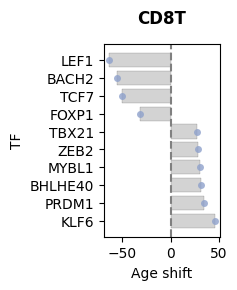

In [79]:
from ciim.src.insilico_perturbation.plots import wrapper_plot_age_acceleration_for_tf_perturbation

value_col= 'mean_diff'#'signed_neg_log10_pval'
features = None

top_tfs_dict = {}
for cell_type in perturb_rr_mean['cell_type'].unique():
    perturb_rr_mean_t = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type]

    if True:
        # filter for sig aging TFs
        aging_stats = retrieve_sig_stats(type='bulk')
        aging_tfs = aging_stats[aging_stats['cell_type'] == cell_type]['tf'].unique()
        perturb_rr_mean_t = perturb_rr_mean_t[perturb_rr_mean_t['tf'].isin(aging_tfs)]
    aa, top_tfs = wrapper_plot_age_acceleration_for_tf_perturbation(perturb_rr_mean_t, 
                                            value_col=value_col, 
                                            top_n=10,
                                            figsize=(1.5, 2.5))
    plt.legend().remove()
    top_tfs_dict[cell_type] = top_tfs
    plt.title(f"{cell_type}", pad=15, weight='bold')

## Aging trends: verification

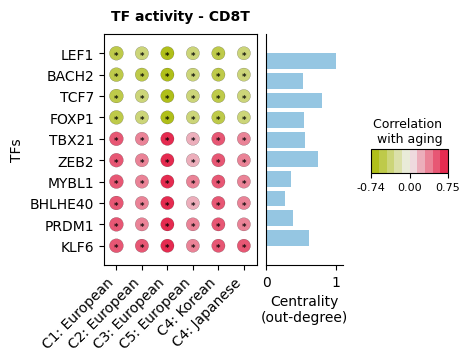

In [80]:
value_col = 'mean_diff'
for cell_type in perturb_rr_mean['cell_type'].unique():
    top_tfs = top_tfs_dict[cell_type]
    df_cell = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type].copy()
    

    # median_abs = df_cell.groupby('tf')[value_col].apply(lambda x: x.abs().median())

    # Keep only top TFs
    df_cell = df_cell[df_cell['tf'].isin(top_tfs)].copy()

    # Sort TFs by signed mean_diff for plotting
    tf_order = df_cell.groupby('tf')[value_col].mean().sort_values().index
    df_cell['tf'] = pd.Categorical(df_cell['tf'], categories=tf_order, ordered=True)
    df_cell['tf'].cat.categories

    features = df_cell['tf'].cat.categories
    from ciim.src.tf_activity.plots import plot_features_vs_datasets
    bb = plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features, feature_type='tf_activity', sizes=(90, 100), width=4)

## Consistency of the age shift with aging TFs: verification 

In [ ]:
# Import dependencies
from ciim.src.tf_activity.helper import retrieve_sig_stats

# Get the sign of slope for perturbation analysis
# perturb_rr_sig = perturb_rr[perturb_rr['signed_neg_log10_pval'].abs()>1.4]
perturb_slope_sign = (
    perturb_rr_mean.groupby(['cell_type', 'tf'])['mean_diff']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'mean_diff': 'slope'})
)


# Get the sign of slope for aging TFs (reference)
stats = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['tf', 'cell_type'])
aging_slope_sign = (
    stats.groupby(['cell_type', 'tf'])['slope']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'slope': 'slope'})
)

# Cell type-specific overlap
overlap_results = []

for cell_type in cell_types:
    # Subset aging (reference) and perturbation data
    aging_t = aging_slope_sign[aging_slope_sign['cell_type'] == cell_type]
    perturb_t = perturb_slope_sign[perturb_slope_sign['cell_type'] == cell_type]
    # Merge on TFs that are found in both
    merged = aging_t.merge(perturb_t, on='tf', suffixes=('_aging', '_perturb'), how='inner')

    if merged.empty:
        continue

    # Count matches with respect to aging slope
    matched = (merged['slope_aging'] == merged['slope_perturb']).sum()
    total = merged.shape[0]
    fraction_matched = matched / total

    overlap_results.append({
        'cell_type': cell_type,
        'n_ref_tfs': len(aging_t),
        'n_overlap_tfs': total,
        'n_matched': matched,
        'fraction_matched': fraction_matched
    })


overlap_df = pd.DataFrame(overlap_results)
overlap_df

,cell_type,n_ref_tfs,n_overlap_tfs,n_matched,fraction_matched
0,CD8T,163,163,139,0.852761


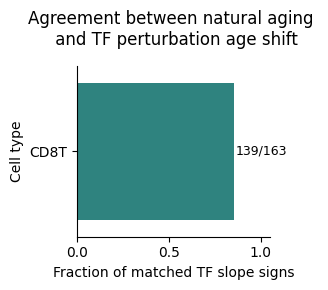

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tf_slope_overlap(overlap_df):
    fig, ax = plt.subplots(figsize=(3, 3))

    # Plot the bars
    barplot = sns.barplot(
        data=overlap_df,
        x='fraction_matched',
        y='cell_type',
        ax=ax,
        palette='viridis'
    )

    # Add text labels directly on the bars
    for bar, (_, row) in zip(barplot.patches, overlap_df.iterrows()):
        width = bar.get_width()
        y_center = bar.get_y() + bar.get_height() / 2
        label = f"{int(row['n_matched'])}/{int(row['n_overlap_tfs'])}"

        if width > 0.9:
            ax.text(width - 0.02, y_center, label, va='center', ha='right', fontsize=9, color='white')
        else:
            ax.text(width + 0.01, y_center, label, va='center', ha='left', fontsize=9, color='black')

    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Fraction of matched TF slope signs')
    ax.set_ylabel('Cell type')
    ax.set_title('Agreement between natural aging \n and TF perturbation age shift', pad=15)
    sns.despine()
    plt.tight_layout()
    return fig

# Usage
aa = plot_tf_slope_overlap(overlap_df[overlap_df['cell_type'].isin(['CD4T', 'CD8T', 'MONO', 'NK'])])

# Combinatorial aging TFs perturbation

In [50]:
datasets = datasets_all

In [83]:
def run_all_aging_tf_perturbation():
    print('Running all aging TF perturbation...')
    par_aging = {
        'simulation_iteration': simulation_iteration,
        'n_donors': n_donors,
        'data_type': data_type,
        'version': version,
        'reg_type': reg_type,
        'feature_type': 'gene_expression',
        'perturbation_mode': 'natural_aging',
        'perturbation_type': 'multi',
        'tfs': 'aging',
    }
    df_all = wrapper_in_silico_perturbation(par_aging, n_jobs=n_jobs, cell_types=cell_types, datasets=datasets)
    return df_all
df_all = run_all_aging_tf_perturbation()

Running all aging TF perturbation...
Processing: CD8T - data12 (natural_aging | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for PANCREAS BETA CELLS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Mitochondrial DNA instability: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Telomere attrition: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Alterations in DNA methylation: Error calcu

Text(0.5, 1.25, 'Combinatorial perturbation of aging TFs: CD8T')

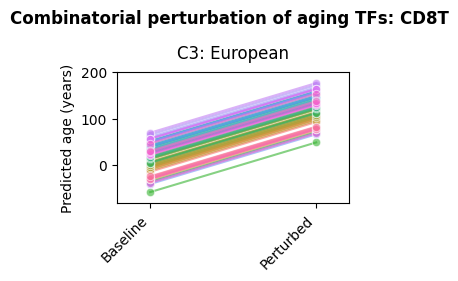

In [ ]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_all['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_all[(df_all['cell_type'] == cell_type) & (df_all['dataset'] == dataset)].copy()
    df = df['age_shift'].copy()

    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD8T']


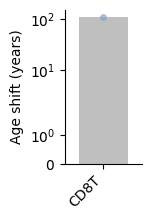

In [98]:
df_mean = df_all.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
fig = plot_age_acceleration(df_mean[df_mean['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], 
                            log_y=True, figsize=(1, 2),
                            margins=(0.3, 0.4))
plt.legend().remove()
# plt.title('Combinatorial perturbation of aging TFs\n (natural aging mode)', pad=15)

# Combinatorial perturbation of SLE associated aging TFs

In [99]:
# --- SLE TF Perturbation ---
def retrieve_sig_stats_disease(dataset='', feature_type='tf_activity', test_type='unpaired', type='bulk'):
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    return stats_drug[(stats_drug['p_value_adj'] < 0.05) & (stats_drug['age_group'] == 'Both age groups')].copy()

def get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig):
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_disease_sig = stats_disease_sig[['cell_type', 'tf', 'slope_condition']].drop_duplicates()
    stats_both = stats_aging_sig.merge(stats_disease_sig, on=['cell_type', 'tf'], how='inner')
    return stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type']]


In [100]:
def run_sle_tf_perturbation():
    print('Running SLE TF perturbation...')
    dataset = 'SLE_European'
    stats_disease_sig = retrieve_sig_stats_disease(dataset=dataset)
    if True: # overlap with aging TFs
        slope_sle = get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig)
    else: # SLE TFs
        slope_sle = stats_disease_sig[['tf','cell_type','slope_condition']].set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type']]
        print(slope_sle.groupby('cell_type').size())
    slope_sle['slope'] = np.sign(slope_sle['slope']) 
    par_sle = {
        'simulation_iteration': simulation_iteration,
        'n_donors': n_donors,
        'data_type': data_type,
        'version': version,
        'reg_type': reg_type,
        'feature_type': 'gene_expression',
        'perturbation_mode': None,
        'perturbation_type': 'multi',
        'slope_df': slope_sle,
    }
    df_sle = wrapper_in_silico_perturbation(par_sle, n_jobs=1, cell_types=cell_types, datasets=datasets_all)
    return df_sle
df_sle = run_sle_tf_perturbation()

Running SLE TF perturbation...
Processing: CD8T - data1 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for PANCREAS BETA CELLS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Mitochondrial DNA instability: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Telomere attrition: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Alterations in DNA methylation: Error calculating gene scor

Text(0.5, 1.25, 'Combinatorial perturbation of SLE-affected aging TFs: CD8T')

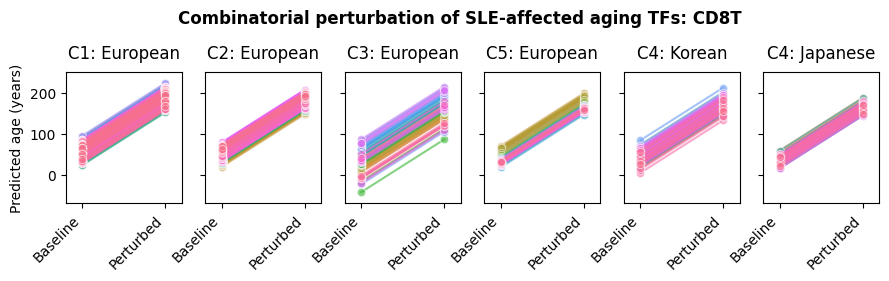

In [ ]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_sle['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_sle[(df_sle['cell_type'] == cell_type) & (df_sle['dataset'] == dataset)].copy()
    df = df['age_shift'].reset_index()
    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of SLE-affected aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD8T']


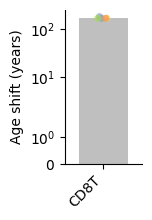

In [ ]:
df_mean = df_sle.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
fig = plot_age_acceleration(df_mean[df_mean['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], log_y=True,
                               figsize=(1, 2),
                            margins=(0.3, 0.4))
plt.legend().remove()

# plt.title(f'Perturbation of aging TFs \n associated with SLE disease', pad=15)

# Drug perturbation

In [105]:
# --- Drug Perturbation ---
def retrieve_sig_stats_drug(feature_type='tf_activity', dataset='CXCL9', test_type='paired', type='bulk'):
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    return stats_drug[(stats_drug['p_value_adj'] < 0.05)].copy()

def get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig):
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_drug_sig = stats_drug_sig[['cell_type', 'tf', 'slope_condition', 'comparision']].drop_duplicates()
    stats_both = stats_aging_sig.merge(stats_drug_sig, on=['cell_type', 'tf'], how='inner')
    return stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type', 'comparision']]

In [106]:
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
def run_perturbation_tf_perturbation():
    print('Running drug perturbation TF perturbation...')
    stats_drug_sig = retrieve_sig_stats_drug(dataset='CXCL9')
    if True: # overlapping TFs
        df_slope = get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig)
    else:
        df_slope = stats_drug_sig.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type', 'comparision']]
    print(df_slope.groupby(['cell_type', 'comparision']).size())
    df_slope['slope'] = np.sign(df_slope['slope'])
    df_slope.head()
    df_store = []
    for comparision in tqdm(df_slope['comparision'].unique()):
    # for comparision in ['Ruxolitinib (ctr: LPS)']:
        df_slope_c = df_slope[df_slope['comparision'] == comparision].copy()

        par = {
            'simulation_iteration': simulation_iteration,
            'n_donors': n_donors,
            'data_type': data_type,
            'version': version,
            'reg_type': reg_type,
            'feature_type': 'gene_expression',
            'perturbation_mode': None,
            'perturbation_type': 'multi',
            'slope_df': df_slope_c,
        }
        df_all_c = wrapper_in_silico_perturbation(par, 
                                    n_jobs=n_jobs,
                                    cell_types=cell_types,
                                    datasets=['data12']# aging_clock_train_datasets, #['data12'] # datasets_all
                                    )
        df_all_c['comparision'] = comparision
        df_store.append(df_all_c)
    df_all = pd.concat(df_store)
    # df_all.to_csv(f"{save_dir}/perturbation/tf_screen_results_drug_perturbation.csv")
    return df_all
df_all = run_perturbation_tf_perturbation()



Running drug perturbation TF perturbation...
cell_type  comparision            
CD4T       LPS (ctr: RPMI)             49
           Ruxolitinib (ctr: LPS)       1
CD8T       LPS (ctr: RPMI)             38
           Ruxolitinib (ctr: LPS)     106
MONO       LPS (ctr: RPMI)             28
           Metformin (ctr: LPS)        21
           Metformin (ctr: RPMI)       19
           Ruxolitinib (ctr: LPS)      34
           Ruxolitinib (ctr: RPMI)     39
NK         LPS (ctr: RPMI)             22
           Ruxolitinib (ctr: LPS)       1
dtype: int64


  0%|          | 0/5 [00:00<?, ?it/s]

Processing: CD8T - data12 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for PANCREAS BETA CELLS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Mitochondrial DNA instability: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.


 20%|██        | 1/5 [00:05<00:20,  5.00s/it]

Error calculating gene scores for Telomere attrition: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Alterations in DNA methylation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for AMPK pathway dysregulation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for SIRT pathway dysregulation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Processing: CD8T - data12 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is

...

Error calculating gene scores for Telomere attrition: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Alterations in DNA methylation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for AMPK pathway dysregulation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for SIRT pathway dysregulation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Processing: CD8T - data12 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is

 80%|████████  | 4/5 [00:19<00:04,  4.91s/it]

Error calculating gene scores for Telomere attrition: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Alterations in DNA methylation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for AMPK pathway dysregulation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for SIRT pathway dysregulation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Processing: CD8T - data12 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is

100%|██████████| 5/5 [00:24<00:00,  4.94s/it]

Error calculating gene scores for Telomere attrition: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for Alterations in DNA methylation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for AMPK pathway dysregulation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for SIRT pathway dysregulation: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.


In [26]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
if False: # donor level plots
    from ciim.src.insilico_perturbation.helper import perform_stat_test
    cell_type = cell_types[0]
    for comparision in df_all['comparision'].unique():
        print(comparision)
        datasets = df_all['dataset'].unique()
        n_datasets = len(datasets)
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            df = df_all[(df_all['cell_type'] == cell_type) & (df_all['dataset'] == dataset)  & (df_all['comparision'] == comparision)].copy()
            df = df['age_shift'].reset_index()
            # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
            # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')
    # comparision = 'Ruxolitinib (ctr: LPS)'
    # datasets = df_all['dataset'].unique()
    # n_datasets = len(datasets)
    # fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
    # for i, dataset in enumerate(datasets):
    #     ax = axes[i] if n_datasets > 1 else axes
    #     df = df_all[(df_all['cell_type'] == cell_type) & (df_all['dataset'] == dataset)  & (df_all['comparision'] == comparision)].copy()

    #     # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    #     # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    #     plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    #     ax.set_title(f"{surrogate_names[dataset]}", pad=10)

    # plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')

['CD8T']


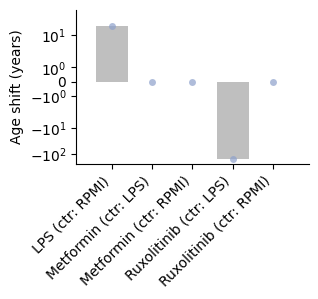

In [110]:
for cell_type in df_all['cell_type'].unique():
    df = df_all[df_all['cell_type'] == cell_type].copy()
    # df_mean = df.groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median().reset_index(name='mean_diff')
    df_mean = df.groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
    plot_age_acceleration(df_mean, x_col='comparision', log_y=True, figsize=(3, 2),
                            margins=(0.1, 0.4))
    plt.legend().remove()
    # plt.title(f"{cell_type} - Perturbation of aging TFs \n associated with drugs", pad=15)